# Part 2: What Can We Do with Vision-Language Models?

## Lesson Overview

A vision-language model works like a language model, but now it can use both **text and images**.

When you prompt the model, think of it like giving instructions to an intern who can **see the image**. If you are vague, the model will describe things broadly. If you are clear, it will give you exactly what you want.

We will go through common tasks:

* describing images
* answering questions
* classification
* extracting information

# Example 0: Why Clear Prompts Matter

## Step 1: A vague prompt

In [20]:
from utils import preprocess_image_to_data_url
from IPython.display import display, Markdown
from PIL import Image
import matplotlib.pyplot as plt

from openai import OpenAI

key = "gpustack_d230867d00abae37_390e4dac2dd24f61c4e2f6971c403883"
client = OpenAI(base_url="http://10.246.100.230/v1", api_key=key)

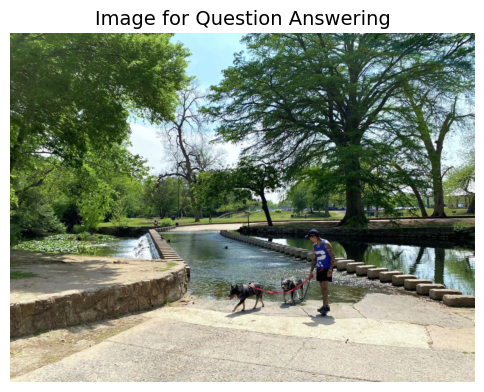

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

# Load image
img = Image.open("./datasets/demo-images/sa-park.jpeg")

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Image for Question Answering", fontsize=14)
plt.show()

In [11]:

prompt = """
Write about this image.
"""

# =========================
# RUN MODEL (DO NOT MODIFY)
# =========================

path = "./datasets/demo-images/sa-park.jpeg"

img_url = preprocess_image_to_data_url(path)

resp = client.chat.completions.create(
    model="qwen3-vl-32b-instruct",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": img_url}},
            ],
        }
    ],
    temperature=0.2,
    max_tokens=1000,
)

print(resp.choices[0].message.content)

This image captures a peaceful, sunlit scene in what appears to be a park or natural reserve, centered around a calm, man-made water feature. The composition is framed by lush green trees with full, vibrant foliage, suggesting it is spring or summer. The sky is bright and mostly clear, casting soft shadows and highlighting the natural textures of the stone and water.

In the foreground, a paved path leads toward a small, rectangular pond or canal bordered by low stone walls. A man stands on the path, wearing a blue sleeveless athletic shirt with a white number "5" on the front, black shorts, and a dark cap. He has visible tattoos on his arms and legs and is holding a red leash attached to two dogs. The dogs, both medium-sized with dark coats—possibly black or brindle—walk ahead of him, one slightly ahead of the other, appearing alert and engaged with their surroundings.

The water feature includes a small, stepped spillway or weir on the left, where water gently cascades down into the 


## Step 2: A clear prompt

In [13]:
prompt = """
Write exactly 3 sentences describing what is happening in this image.
Focus on what people are doing and the overall atmosphere. Use three bullet points. Keep sentences short.
"""

# =========================
# RUN MODEL (DO NOT MODIFY)
# =========================

path = "./datasets/demo-images/sa-park.jpeg"
img_url = preprocess_image_to_data_url(path)

resp = client.chat.completions.create(
    model="qwen3-vl-32b-instruct",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": img_url}},
            ],
        }
    ],
    temperature=0.2,
    max_tokens=1000,
)

print(resp.choices[0].message.content)

- A man in a blue tank top and black shorts walks two dogs on leashes along a paved path beside a calm pond.  
- The dogs, one black and one gray, trot ahead as he guides them near a stone-lined water feature with a small cascade.  
- Lush green trees surround the area under a bright sky, creating a peaceful, sunny park atmosphere.


Now the model knows:

* what to focus on
* how long the answer should be
* what kind of answer you want

In general, you should also specify the format the output should be returned in so that the model is consistent.

# Example 1: Visual Question Answering

### Task

Ask a specific question about the image.

In [16]:

prompt = """
How many people are in the image? Answer in one short sentence.
"""

# =========================
# RUN MODEL (DO NOT MODIFY)
# =========================

path = "./datasets/demo-images/sa-park.jpeg"

img_url = preprocess_image_to_data_url(path)

resp = client.chat.completions.create(
    model="qwen3-vl-32b-instruct",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": img_url}},
            ],
        }
    ],
    temperature=0.2,
    max_tokens=1000,
)

print(resp.choices[0].message.content)

There is one person in the image.


# Example 2: Image Classification

### Task

Assign one label to the image.

In [17]:

prompt = """
Return one label only from:
[food truck, restaurant, park, classroom]
"""

# =========================
# RUN MODEL (DO NOT MODIFY)
# =========================

path = "./datasets/demo-images/sa-park.jpeg"

img_url = preprocess_image_to_data_url(path)

resp = client.chat.completions.create(
    model="qwen3-vl-32b-instruct",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": img_url}},
            ],
        }
    ],
    temperature=0.2,
    max_tokens=1000,
)

print(resp.choices[0].message.content)


park


# Example 3: Information Extraction from Images

### Task

Extract structured information from the image.

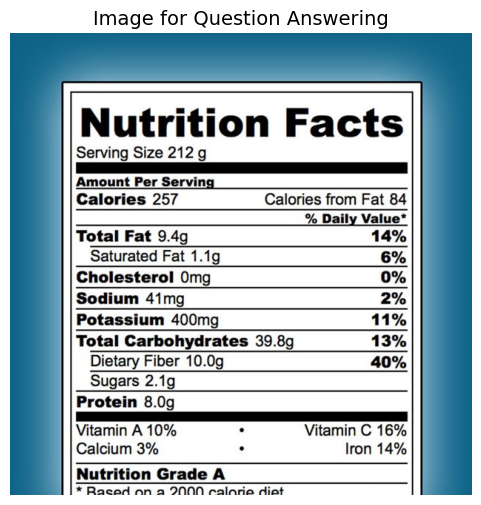

In [18]:
from PIL import Image
import matplotlib.pyplot as plt

# Load image
img = Image.open("./datasets/demo-images/nutrition-facts.jpg")

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Image for Question Answering", fontsize=14)
plt.show()

In [5]:
prompt = """
Extract the nutritional facts from this image.
"""

# =========================
# RUN MODEL (DO NOT MODIFY)
# =========================

path = "./datasets/demo-images/nutrition-facts.jpg"

img_url = preprocess_image_to_data_url(path)

resp = client.chat.completions.create(
    model="qwen3-vl-32b-instruct",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": img_url}},
            ],
        }
    ],
    temperature=0.2,
    max_tokens=1000,
)

print(resp.choices[0].message.content)

Here are the extracted nutritional facts from the image:

---

**Nutrition Facts**

- **Serving Size:** 212 g  
- **Amount Per Serving:**
  - **Calories:** 257  
  - **Calories from Fat:** 84  

- **% Daily Value*** (based on a 2000 calorie diet)

  - **Total Fat:** 9.4g — 14%  
    - Saturated Fat: 1.1g — 6%  
  - **Cholesterol:** 0mg — 0%  
  - **Sodium:** 41mg — 2%  
  - **Potassium:** 400mg — 11%  
  - **Total Carbohydrates:** 39.8g — 13%  
    - Dietary Fiber: 10.0g — 40%  
    - Sugars: 2.1g  
  - **Protein:** 8.0g  

- **Vitamins & Minerals:**
  - Vitamin A: 10%  
  - Vitamin C: 16%  
  - Calcium: 3%  
  - Iron: 14%  

- **Nutrition Grade:** A  

*Based on a 2000 calorie diet

---

Note: The image is partially cut off at the bottom, so some additional information (like other vitamins or ingredients) may be missing.


# Exercise 1: UT Austin vs UT San Antonio Classification

## Input
You will be given an image.

## Output
Your prompt must make the model return exactly one of the following:

Class: UT Austin  
Class: UT San Antonio  

## Task
Write one prompt for a vision-language model that looks at the input image and predicts the correct class.

Your prompt must work for all four images.

## Rules
- The output must be exactly one line  
- The output must start with Class:  
- The output must be exactly one of the two options above  
- Do not include explanations  
- Do not include extra words or punctuation  
- Do not include multiple lines  


In [21]:
from utils import preprocess_image_to_data_url
from IPython.display import display, Markdown
from PIL import Image
import matplotlib.pyplot as plt

from openai import OpenAI

key = "gpustack_d230867d00abae37_390e4dac2dd24f61c4e2f6971c403883"
client = OpenAI(base_url="http://10.246.100.230/v1", api_key=key)

# Image paths
image_paths = [
    "./datasets/birds-vs-horns/horns-1.jpeg",
    "./datasets/birds-vs-horns/birds-up-2.jpeg",
    "./datasets/birds-vs-horns/horns-2.jpg",
    "./datasets/birds-vs-horns/birds-up-1.jpg",
]

# Titles shown to students
titles = [
    "Image 1",
    "Image 2",
    "Image 3",
    "Image 4",
]

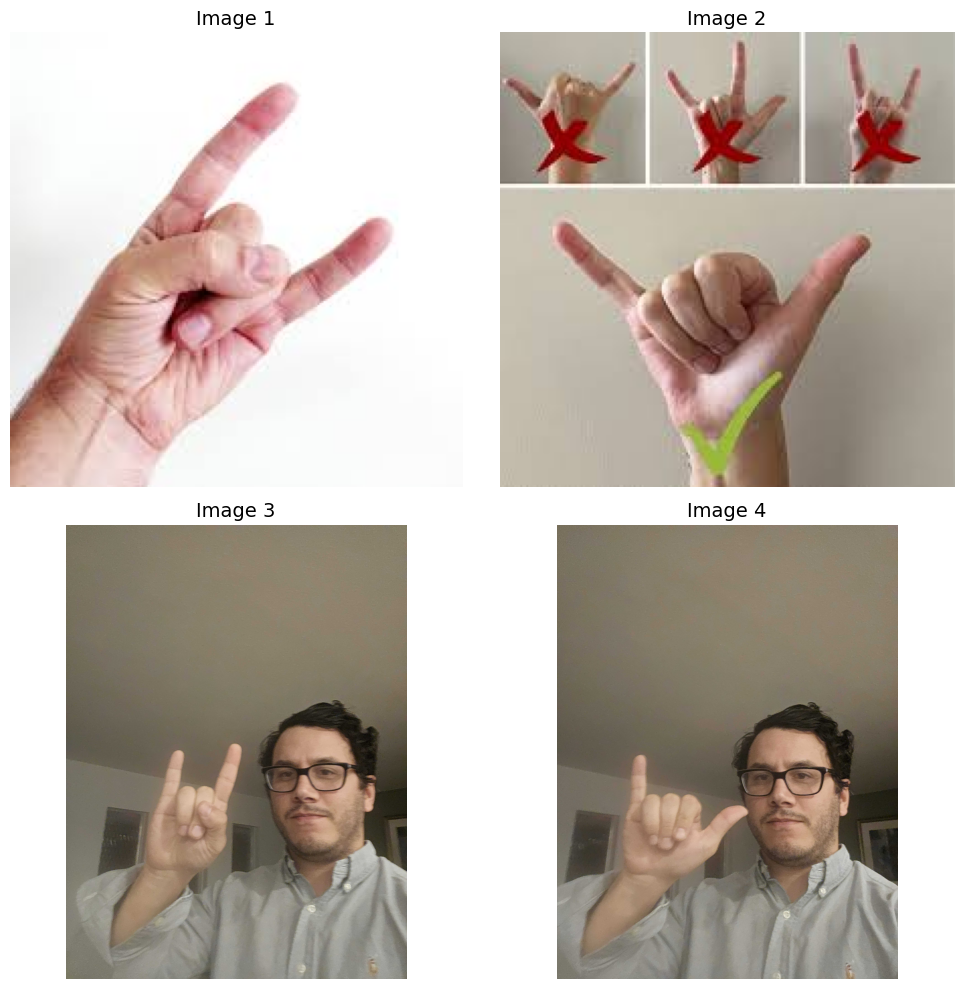

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, path, title in zip(axes, image_paths, titles):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:

# =========================
# STUDENT SECTION (EDIT THIS ONLY)
# =========================
prompt = """
Is this hand sign UT San Antonio (UTSA) or UT Austin?
"""

# =========================
# RUN MODEL (DO NOT MODIFY)
# =========================
for i, path in enumerate(image_paths):
    img_url = preprocess_image_to_data_url(
        path,
        max_side=1024,
        format="JPEG",
        jpeg_quality=90,
        pad_to_square=False
    )

    resp = client.chat.completions.create(
        model="qwen3-vl-32b-instruct",
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": img_url}},
            ],
        }],
        temperature=0.1,
        max_tokens=512,
    )

    print(f"Image {i+1} Prediction:")
    print(resp.choices[0].message.content.strip())
    print("-" * 40)

Image 1 Prediction:
The hand sign shown — with the index and pinky fingers extended and the middle and ring fingers curled down — is commonly known as the **"devil horns"** or **"rock on"** gesture. While it is often associated with rock music and heavy metal culture, it is **not** the official hand sign for either **UTSA (University of Texas at San Antonio)** or **UT Austin (University of Texas at Austin)**.

However, **UT Austin** has a well-known hand sign called the **"Hook 'em Horns"**, which is **very similar** — it involves extending the index and pinky fingers while curling the middle and ring fingers, just like the gesture in the image. The key difference is that the **"Hook 'em Horns"** is typically done with the **thumb tucked in** (not extended), and the hand is often held with the palm facing forward or sideways, sometimes with a slight hook motion.

In the image you provided, the **thumb is visible and appears to be extended or slightly curled**, which is **not** the clas

## Excercise 2: OCR + Structured Extraction from Receipts

In this task, you will use a Vision-Language Model (VLM) to read HEB grocery receipts and extract structured data.

### Goal

Write a **prompt** that makes the model:

1. Read the receipt (OCR)
2. Extract:
   * Item names
   * Item prices
3. Return the results in **CSV format**


### Expected Output Format

Your output should look like this:

```
TRAIL MIX PEANUT M&MS,3.64
DELUXE MIXED NUTS,5.41
WHOLE MILK 64OZ,1.72
SPARKLING WATER,3.79
```

### Requirements

* Include only purchased items (ignore discounts, totals, savings, and payment details)
* Each row should contain:

  * item name
  * price
* Output must be:

  * clean
  * consistent
  * valid CSV format (comma-separated, no extra commentary)


### Your Task

Modify the `prompt` variable in the code to:

* Clearly instruct the model to extract the correct information
* Ensure the output follows the required CSV format exactly

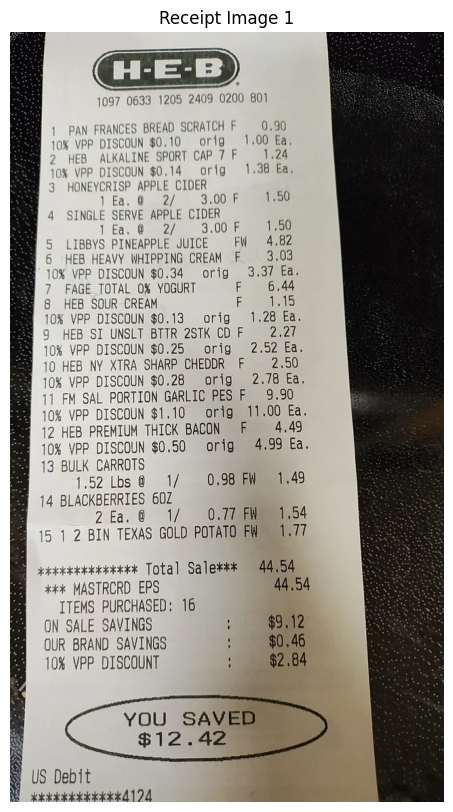

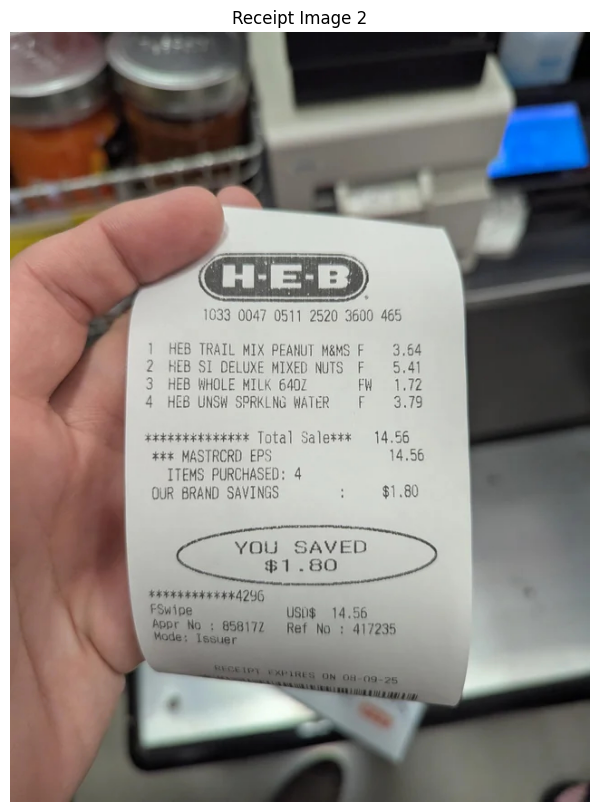

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

# =========================
# STUDENT SECTION (EDIT THIS ONLY)
# =========================
image_paths = [
    "./datasets/receipts/receipt-1.jpeg",
    "./datasets/receipts/receipt-2.jpeg",
]

# =========================
# DISPLAY IMAGES
# =========================
for i, path in enumerate(image_paths):
    img = Image.open(path)
    plt.figure(figsize=(8, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Receipt Image {i+1}")
    plt.show()

In [12]:

prompt = """
Extract stuff from that receipt man.
"""


# =========================
# RUN MODEL (DO NOT MODIFY)
# =========================
for i, path in enumerate(image_paths):
    img_url = preprocess_image_to_data_url(path)

    resp = client.chat.completions.create(
        model="qwen3-vl-32b-instruct",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": img_url}},
                ],
            }
        ],
        temperature=0.2,
        max_tokens=1000,
    )

    print(f"\n{'='*60}")
    print(f"Receipt Image {i+1}: {path}")
    print(f"{'='*60}")
    print(resp.choices[0].message.content)


Receipt Image 1: ./datasets/receipts/receipt-1.jpeg
Here’s a detailed breakdown of the receipt from **H-E-B**:

---

### 🛒 **Store Info**
- **Store ID**: 1097 0633 1205 2409 0200 801
- **Store Name**: H-E-B

---

### 📋 **Items Purchased (16 Items Total)**

| # | Item Description                     | Quantity | Price/Unit | Total Price | Notes/Discounts |
|---|------------------------------------|----------|------------|-------------|-----------------|
| 1 | PAN FRANCES BREAD SCRATCH F          | 1        | $0.90      | $0.90       | 10% VPP Disc: $0.10 |
| 2 | HEB ALKALINE SPORT CAP 7 F           | 1        | $1.24      | $1.24       |                 |
| 3 | HONEYCRISP APPLE CIDER             | 1 Ea. @ 2/3.00 | $1.50 | $1.50       |                 |
| 4 | SINGLE SERVE APPLE CIDER           | 1 Ea. @ 2/3.00 | $1.50 | $1.50       |                 |
| 5 | LIBBYS PINEAPPLE JUICE             | 1        | $4.82      | $4.82       |                 |
| 6 | HEB HEAVY WHIPPING CREAM       

## Exercise 3: Accessible Descriptions of Line Graphs

### Scenario

You are building an AI system to help **visually impaired users** understand charts.

Your task is to write a prompt that makes the model generate a **clear, concise, and accessible description of a line graph**.

### Important Constraint

You will **write your prompt BEFORE seeing the graphs**.

This is intentional.

You must:

* think carefully about what information is important
* imagine what the graph might look like
* design a prompt that works for many different graphs

### Goal

Your prompt should make the model describe:

* the **overall trend** (increasing, decreasing, flat, fluctuating)
* any **major changes** (sharp rises, drops, peaks)
* important **regions or segments**
* key **comparisons** (if multiple lines exist)

### Style Requirements

The output should be:

* clear and easy to understand
* concise (2–4 sentences)
* written for someone who **cannot see the graph**

Avoid:

* unnecessary detail
* guessing exact values unless clearly visible
* long or complex explanations

### Task

Write a prompt that tells the model how to describe a line graph.

Your prompt should:

* explain what to focus on
* specify the length and style
* guide the model toward useful descriptions

### Example (Bad Prompt)

```text
Describe this graph.
```

Too vague. The model may:

* list random details
* miss important trends
* produce long or unhelpful output



In [25]:
from utils import preprocess_image_to_data_url
from IPython.display import display, Markdown
from PIL import Image
import matplotlib.pyplot as plt

from openai import OpenAI

key = "gpustack_d230867d00abae37_390e4dac2dd24f61c4e2f6971c403883"
client = OpenAI(base_url="http://10.246.100.230/v1", api_key=key)

# Image paths
image_paths = [
    "./datasets/graphs/interest-rates.png",
    "./datasets/graphs/polio.jpeg"
]

# Titles shown to students
titles = [
    "Image 1",
    "Image 2",
]


In [ ]:
# =========================
# STUDENT SECTION (EDIT THIS ONLY)
# =========================
prompt = """
[Write your prompt here]
"""


# =========================
# RUN MODEL (DO NOT MODIFY)
# =========================
for i, path in enumerate(image_paths):
    img_url = preprocess_image_to_data_url(path)

    resp = client.chat.completions.create(
        model="qwen3-vl-32b-instruct",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": img_url}},
                ],
            }
        ],
        temperature=0.2,
        max_tokens=1000,
    )

    print(f"\n{'='*60}")
    print(f"Graph {i+1}: {path}")
    print(f"{'='*60}")
    print(resp.choices[0].message.content)

### Think Before Running

Before you run the model, ask yourself:

* If I could not see the graph, would this description help me understand it?
* Does my prompt force the model to describe trends and key changes?
* Is the output short and useful?

In [ ]:
# ONLY RUN THIS AFTER COMPLETING THE ABOVE PROMPTS

fig, axes = plt.subplots(1, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, path, title in zip(axes, image_paths, titles):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()